In [1]:
import os
import gc
import rasterio
import numpy as np
import geopandas as gpd
from rasterio.enums import Resampling
from rasterio.mask import mask

# ==========================================
# 1. PATH
# ==========================================
#folder_path
folder_path = r'./mosaic_2025.data'
boundary_shp = folder_path+'/vector/studyarea_MKDelta.shp'
output_tif_normalized = folder_path+'/stacked_cropped_2025_norm.tif'

# Biến toàn cục lưu dữ liệu mẫu nhẹ để phục vụ vẽ hình ở Cell 2
plot_samples_dict = {}

# ==========================================
# 2. Data Preparation and Grid
# ==========================================
img_files = sorted([os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.img')])
if not img_files:
    raise FileNotFoundError("NO found file .img!")

gdf = gpd.read_file(boundary_shp)

with rasterio.open(img_files[0]) as src_ref:
    ref_crs = src_ref.crs
    nodata_val = src_ref.nodata if src_ref.nodata is not None else -9999

if gdf.crs != ref_crs:
    gdf = gdf.to_crs(ref_crs)
geoms = gdf.geometry.values

with rasterio.open(img_files[0]) as src_ref:
    ref_cropped, target_transform = mask(src_ref, geoms, crop=True, nodata=nodata_val)
    target_shape = ref_cropped.shape

n_bands = len(img_files)
out_meta = {
    "driver": "GTiff",
    "dtype": "float32",
    "nodata": 0.0,
    "width": target_shape[2],
    "height": target_shape[1],
    "count": n_bands,
    "crs": ref_crs,
    "transform": target_transform
}

# ==========================================
# 3. DATA processing and samples extraction
# ==========================================
print(f"Processing {n_bands} bands and data extraction...")

with rasterio.open(output_tif_normalized, "w", **out_meta) as dst:
    for i, file_path in enumerate(img_files):
        file_name = os.path.basename(file_path)
        
        # --- A. Crop & Resample ---
        with rasterio.open(file_path) as src:
            band_nodata = src.nodata if src.nodata is not None else nodata_val
            cropped_data, cropped_transform = mask(src, geoms, crop=True, nodata=band_nodata)
            
            if cropped_data.shape != target_shape:
                crop_profile = src.profile.copy()
                crop_profile.update({"height": cropped_data.shape[1], "width": cropped_data.shape[2], "transform": cropped_transform, "nodata": band_nodata})
                with rasterio.MemoryFile() as memfile:
                    with memfile.open(**crop_profile) as mem_dst:
                        mem_dst.write(cropped_data)
                        band_arr = mem_dst.read(out_shape=target_shape, resampling=Resampling.bilinear)[0].astype("float32")
            else:
                band_arr = cropped_data[0].astype("float32")

        # --- B. Preprocessing & Normalization ---
        valid_mask = (band_arr != band_nodata) & np.isfinite(band_arr)
        valid_vals = band_arr[valid_mask]

        if valid_vals.size > 0:
            p1, p99 = np.percentile(valid_vals, (1, 99))
            if valid_vals.max() > p99 * 1.5:
                band_arr[valid_mask] = np.clip(band_arr[valid_mask], p1, p99)
                valid_vals = band_arr[valid_mask]

            if valid_vals.max() > 50 and valid_vals.min() >= 0:
                band_arr[valid_mask] = 10 * np.log10(band_arr[valid_mask] + 1e-6)
                valid_vals = band_arr[valid_mask]

            b_min, b_max = valid_vals.min(), valid_vals.max()
            if b_max > b_min:
                band_arr[valid_mask] = (band_arr[valid_mask] - b_min) / (b_max - b_min)
            else:
                band_arr[valid_mask] = 0.0
        
        band_arr[~valid_mask] = 0.0
        dst.write(band_arr, i + 1) 

        # --- C. Extract 100k pixels and import into RAM for Cell 2 ---
        v_norm = band_arr[valid_mask]
        if v_norm.size > 0:
            sample_size = min(100000, v_norm.size)
            plot_samples_dict[i] = {
                'file_name': file_name,
                'sample': np.random.choice(v_norm, size=sample_size, replace=False),
                'mean': float(np.mean(v_norm)),
                'median': float(np.median(v_norm))
            }

        print(f"✅ Hoàn thành Band {i+1}/{n_bands}: {file_name}")
        del band_arr, valid_mask, valid_vals, v_norm
        gc.collect()

print(f"\n🎉 Completed! File saved at:\n -> {output_tif_normalized}")

Bắt đầu tiền xử lý 12 bands và trích xuất mẫu dữ liệu...
✅ Hoàn thành Band 1/12: C22.img
✅ Hoàn thành Band 2/12: Sigma0_HH.img
✅ Hoàn thành Band 3/12: Sigma0_HH_Contrast.img
✅ Hoàn thành Band 4/12: Sigma0_HH_GLCMCorrelation.img
✅ Hoàn thành Band 5/12: Sigma0_HH_GLCMMean.img
✅ Hoàn thành Band 6/12: Sigma0_HH_GLCMVariance.img
✅ Hoàn thành Band 7/12: Sigma0_HH_Homogeneity.img
✅ Hoàn thành Band 8/12: Sigma0_HV.img
✅ Hoàn thành Band 9/12: Sigma0_HV_GLCMCorrelation.img
✅ Hoàn thành Band 10/12: Sigma0_HV_GLCMMean.img
✅ Hoàn thành Band 11/12: Sigma0_HV_GLCMVariance.img
✅ Hoàn thành Band 12/12: ndvi_2024_re.img

🎉 TIỀN XỬ LÝ HOÀN TẤT! File kết quả lưu tại:
 -> ./mosaic_2025.data/stacked_cropped_2025_norm.tif


--- ĐANG VẼ ĐỒ THỊ CHUẨN Q1 VỚI TÊN BAND MỚI ---


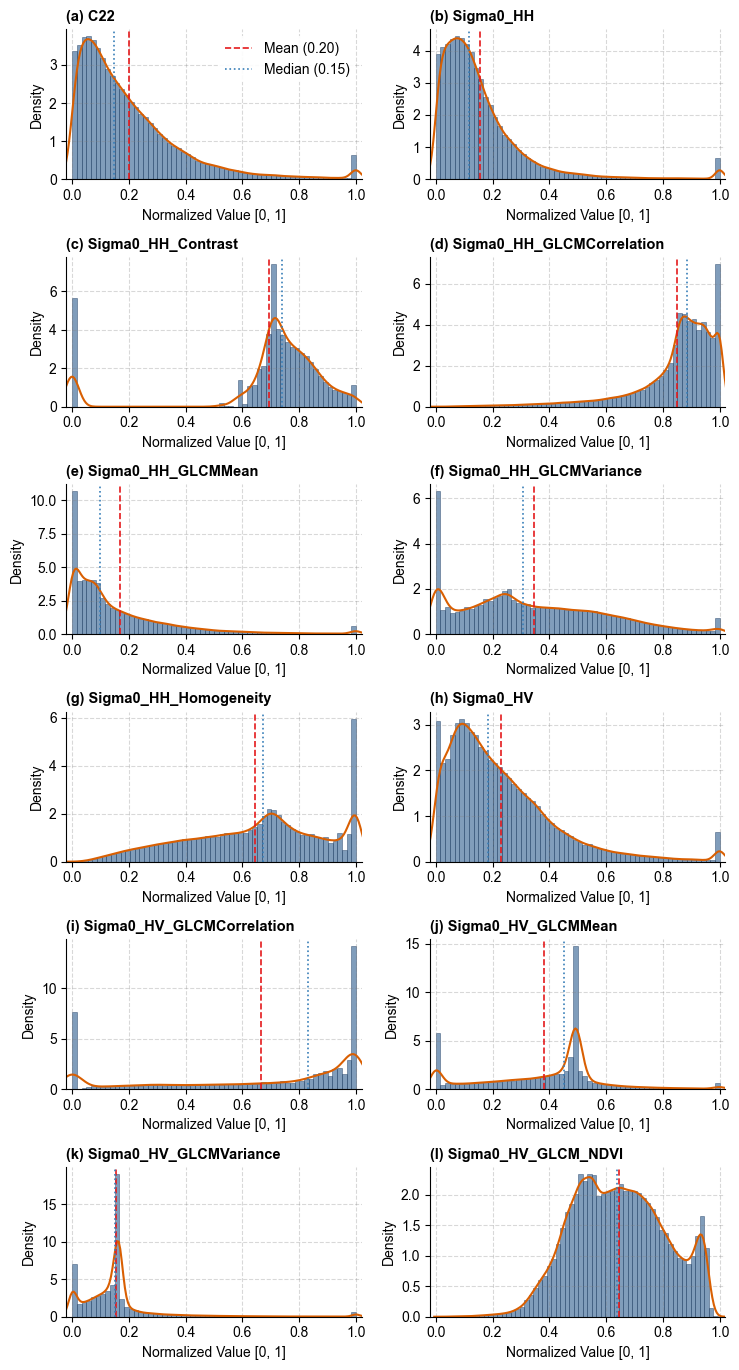

✅ Đã xuất hình thành công!
 -> PNG: ./mosaic_2025.data/Figure_Histograms_Q1.png
 -> PDF: ./mosaic_2025.data/Figure_Histograms_Q1.pdf


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10.5

figure_output_png = folder_path+'/Figure_Histograms_Q1.png'
figure_output_pdf = folder_path+'/Figure_Histograms_Q1.pdf'

# ==========================================
# 1. Band name
# ==========================================
band_names = {
    0: "C22",
    1: "Sigma0_HH",
    2: "Sigma0_HH_Contrast",
    3: "Sigma0_HH_GLCMCorrelation",
    4: "Sigma0_HH_GLCMMean",
    5: "Sigma0_HH_GLCMVariance",
    6: "Sigma0_HH_Homogeneity",
    7: "Sigma0_HV",
    8: "Sigma0_HV_GLCMCorrelation",
    9: "Sigma0_HV_GLCMMean",
    10: "Sigma0_HV_GLCMVariance",
    11: "Sigma0_HV_GLCM_NDVI"
}

print("--- Drawing plot ---")

n_bands = len(plot_samples_dict)
n_cols = 2
n_rows = int(np.ceil(n_bands / n_cols))

# Size of figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.5, 2.3 * n_rows))
axes = axes.flatten()

for i in range(n_bands):
    ax = axes[i]
    band_info = plot_samples_dict[i]
    
    v_sample = band_info['sample']
    b_mean = band_info['mean']
    b_median = band_info['median']
    
    # Assign band name
    current_band_name = band_names.get(i, f"Band {i+1:02d}")

    # 1. Draw Histogram
    ax.hist(v_sample, bins=60, density=True, color='#2b5c8f', alpha=0.6, edgecolor='#1b3b5f', linewidth=0.5)
    
    # 2. Draw KDE
    sns.kdeplot(v_sample, ax=ax, color='#d95f02', linewidth=1.5)

    # 3. Draw Mean & Median
    ax.axvline(b_mean, color='#e41a1c', linestyle='--', linewidth=1.2, label=f'Mean ({b_mean:.2f})')
    ax.axvline(b_median, color='#377eb8', linestyle=':', linewidth=1.2, label=f'Median ({b_median:.2f})')

    # 4. Label and Title
    panel_label = chr(97 + i)  # (a), (b), (c)...
    ax.set_title(f"({panel_label}) {current_band_name}", loc='left', fontweight='bold')
    ax.set_xlabel("Normalized Value [0, 1]")
    ax.set_ylabel("Density")
    ax.set_xlim(-0.02, 1.02)
    ax.grid(True, linestyle='--', alpha=0.3, color='gray')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Legend
    if i == 0:
        ax.legend(frameon=True, facecolor='white', framealpha=0.9, edgecolor='none', loc='upper right')

# Erase subplot if surplus
for i in range(n_bands, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()

# ==========================================
# 2. Expor png
# ==========================================
plt.savefig(figure_output_png, dpi=300, bbox_inches='tight')
plt.savefig(figure_output_pdf, format='pdf', bbox_inches='tight')
plt.show()

print(f"✅ Đã xuất hình thành công!\n -> PNG: {figure_output_png}\n -> PDF: {figure_output_pdf}")